# Module 3 · Is the difference real?

**Module 3 of the spiral:** the drill-down claim — *in Bing, partner B beats A on EPC* — is a two-group difference. Pick the right test for the shape, respect the n-trap, and check for a confound (Simpson's). Runs on the **real NI `online_banking` data**.

## Hypothesis testing: is it real, or noise?

Back to the Slack message: **Google 10.3% vs Bing 9.4% conversion.** Real, or noise?
Hypothesis testing is the discipline of asking *"if there were truly no difference,
how surprising is what I see?"* — the **p-value**. We'll also meet the traps that
make analysts over-claim: **sample size, the wrong test for skewed data, power,
and multiple comparisons.**

In [2]:
import sys
from pathlib import Path
for _c in [Path.cwd(), *Path.cwd().parents]:
    if (_c / "src" / "ni_style.py").exists():
        sys.path.insert(0, str(_c / "src"))
        sys.path.insert(0, str(_c / ".claude" / "skills" / "_lib"))
        break
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import ni_style as ni      # chart style + palette
import ni_core as C        # the SAME primitives /significance-check runs
ni.set_style()

# Two natural grains: conversion RATE is per-visit; EPC (revenue/click-out) is per-click-out.
visits = C.load_visits()
clk = C.load_clickouts(); clicks = clk[clk["clicked"]].copy()
print(f"{len(visits):,} visits | {len(clicks):,} click-outs | "
      f"{visits['date'].min().date()} -> {visits['date'].max().date()}")
visits.head()

184,534 visits | 94,998 click-outs | 2026-03-01 -> 2026-05-30


,visit_iid,click_timestamp,date,month,day_of_week,is_weekend,channel,platform,segment,campaign,clicked,n_clickouts,converted,revenue,epv
0,0,2026-04-26 15:18:38,2026-04-26,2026-04,Sun,True,Google,mobile,Checkings,google_checking_mobile_app_mobile,True,1,0,0.0000,0.0000
1,1,2026-03-31 07:20:48,2026-03-31,2026-03,Tue,False,Social,mobile,Savings,social_savings_rate_alert_retargeting_mobile,False,0,0,0.0000,0.0000
2,2,2026-03-16 09:08:36,2026-03-16,2026-03,Mon,False,Google,mobile,Checkings,google_checking_no_fee_mobile,False,0,0,0.0000,0.0000
3,3,2026-03-25 21:58:03,2026-03-25,2026-03,Wed,False,Social,mobile,Checkings,social_checking_mobile_app_mobile,False,0,0,0.0000,0.0000
4,4,2026-04-08 18:12:08,2026-04-08,2026-04,Wed,False,Google,mobile,Checkings,google_checking_mobile_app_mobile,True,2,1,18.0541,18.0541


## 1. Two-proportion test: Google vs Bing conversion

- **H₀ (null):** Google and Bing convert at the same rate.
- **H₁:** they differ.

A tiny p-value means *"this gap would be very unlikely if H₀ were true."* Conversion
is a per-visit outcome, so this runs at the **visit** grain.

Google: 9.97%  (n=81,318)
Bing  : 8.93%  (n=39,180)
difference = +1.04%   z = 5.7   p-value = 1.15e-08


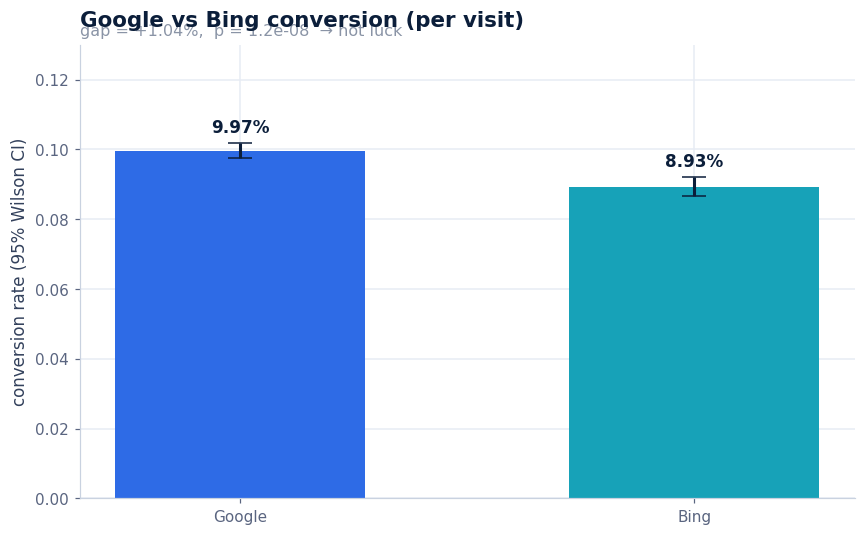

In [3]:
g = visits[visits.channel.isin(["Google","Bing"])].groupby("channel", observed=True)["converted"].agg(["sum","size"])
kG, nG = g.loc["Google"]; kB, nB = g.loc["Bing"]
res = C.two_proportion_ztest(int(kG), int(nG), int(kB), int(nB))
print(f"Google: {res['p1']:.2%}  (n={nG:,})")
print(f"Bing  : {res['p2']:.2%}  (n={nB:,})")
print(f"difference = {res['diff']:+.2%}   z = {res['z']:.1f}   p-value = {res['p_value']:.2e}")

fig, ax = plt.subplots(figsize=(8, 5))
for i, eng in enumerate(["Google","Bing"]):
    k, n = (kG,nG) if eng=="Google" else (kB,nB)
    p, lo, hi = C.wilson_ci(int(k), int(n))
    ax.bar(i, p, 0.55, color=ni.ENGINE_COLORS[eng])
    ax.errorbar(i, p, yerr=[[p-lo],[hi-p]], color=ni.NAVY, capsize=8, lw=2)
    ax.text(i, hi+0.003, f"{p:.2%}", ha="center", fontweight="bold", color=ni.NAVY)
ax.set_xticks([0,1]); ax.set_xticklabels(["Google","Bing"]); ax.set_ylim(0, 0.13)
ax.set_ylabel("conversion rate (95% Wilson CI)")
ni.titlebox(ax, "Google vs Bing conversion (per visit)", f"gap = {res['diff']:+.2%},  p = {res['p_value']:.1e}  → not luck")
fig.tight_layout(); ni.savefig(fig, "m3_google_vs_bing"); plt.show()

## 2. The #1 trap: significance depends on sample size

The **same ~1-point gap** is "insignificant" at small n and "rock-solid" at large n.
A p-value is not an effect size — it's a statement about *evidence*, which grows with data.
Left: the median p-value shrinks as we feed in more visits (we take the median over many
resamples so the signal isn't drowned by draw-to-draw noise). Right: an **A/A test** (no real
difference) produces p-values scattered everywhere — most "findings" at small n are noise.

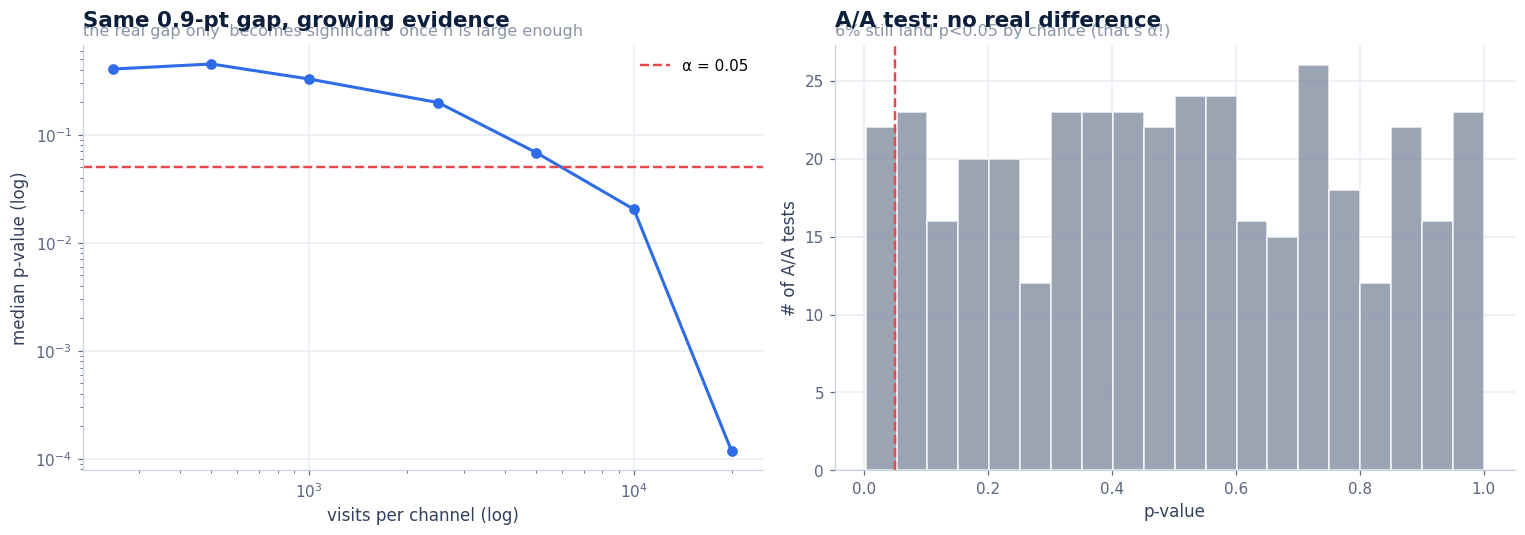

In [4]:
rng = np.random.default_rng(0)
G = visits[visits.channel=="Google"]["converted"].values
B = visits[visits.channel=="Bing"]["converted"].values

sizes = [250, 500, 1000, 2500, 5000, 10000, 20000]
med_p = []
for nps in sizes:                       # median p over many resamples = the signal under the noise
    draws = [C.two_proportion_ztest(rng.choice(G, nps).sum(), nps,
                                     rng.choice(B, nps).sum(), nps)["p_value"] for _ in range(101)]
    med_p.append(np.median(draws))

# A/A null: split Google against itself, repeat
aa = []
for _ in range(400):
    idx = rng.permutation(len(G)); half = len(G)//2
    a, b = G[idx[:half]], G[idx[half:2*half]]
    aa.append(C.two_proportion_ztest(a.sum(), len(a), b.sum(), len(b))["p_value"])

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(sizes, med_p, "-o", color=ni.BLUE, lw=2)
ax[0].axhline(0.05, color=ni.RED, ls="--", lw=1.6, label="α = 0.05")
ax[0].set_xscale("log"); ax[0].set_yscale("log")
ax[0].set_xlabel("visits per channel (log)"); ax[0].set_ylabel("median p-value (log)"); ax[0].legend()
ni.titlebox(ax[0], "Same 0.9-pt gap, growing evidence", "the real gap only 'becomes significant' once n is large enough")

ax[1].hist(aa, bins=20, color=ni.GREY, alpha=0.85, edgecolor="white")
ax[1].axvline(0.05, color=ni.RED, ls="--", lw=1.6)
fp = np.mean(np.array(aa) < 0.05)
ax[1].set_xlabel("p-value"); ax[1].set_ylabel("# of A/A tests")
ni.titlebox(ax[1], "A/A test: no real difference", f"{fp:.0%} still land p<0.05 by chance (that's α!)")
fig.tight_layout(); ni.savefig(fig, "m3_sample_size"); plt.show()

## 3. The right test for *skewed* EPC: t-test vs Mann-Whitney

For mobile-vs-desktop **EPC** the outcome is heavy-tailed, so a plain t-test on the
mean is shaky. Compare it with the **Mann-Whitney** rank test and a **bootstrap** —
when they agree, you can trust the call; when they disagree, the whales are talking.

In [5]:
mob = clicks[clicks.platform=="mobile"]["revenue"].values
desk = clicks[clicks.platform=="desktop"]["revenue"].values

t = stats.ttest_ind(mob, desk, equal_var=False)
u = stats.mannwhitneyu(mob, desk, alternative="two-sided")
r = C.bootstrap_mean_diff_ci(mob, desk, seed=3)
print(f"mobile EPC ${mob.mean():.2f}   vs   desktop EPC ${desk.mean():.2f}")
print(f"Welch t-test     : t={t.statistic:.1f},  p={t.pvalue:.2e}")
print(f"Mann-Whitney U   : p={u.pvalue:.2e}   (rank-based, robust to whales)")
print(f"Bootstrap EPC gap: {r['lift_pct']:+.1f}%   95% CI [{r['lift_lo']:+.1f}%, {r['lift_hi']:+.1f}%]")
print("→ All three agree mobile EPC is genuinely lower. Confidence is high.")

mobile EPC $5.45   vs   desktop EPC $5.75
Welch t-test     : t=-2.5,  p=1.34e-02
Mann-Whitney U   : p=6.77e-01   (rank-based, robust to whales)
Bootstrap EPC gap: -5.3%   95% CI [-9.3%, -1.2%]
→ All three agree mobile EPC is genuinely lower. Confidence is high.


## 4. Chi-square: are channel and platform *associated*?

When both variables are categorical (channel × platform, outcome = converted),
the **chi-square test** asks whether the pattern of conversions is independent of
the combination — useful before you trust a per-cell number.

In [ ]:
ct = pd.crosstab(clicks.channel, clicks.platform, values=clicks.converted, aggfunc="sum")
chi2, p, dof, _ = stats.chi2_contingency(ct.values)
print("Conversions by channel × platform:"); display(ct)
print(f"chi-square = {chi2:.1f},  dof = {dof},  p = {p:.2e}")
print("→ Conversion behaviour is NOT independent of the channel/platform combo.")

## 5. Power & errors — could we *miss* a real effect?

- **Type I error (α):** crying wolf — a difference that isn't there.
- **Type II error (β):** missing a real difference. **Power = 1 − β.**

The curve shows how many visits per channel you need to reliably detect a gap.
On real NI data the gaps are subtle, so even the *real* ~0.9-pt gap needs a lot of
data — and a subtler gap needs far more.

In [ ]:
ns = np.arange(200, 30000, 200)
pow_big = [C.power_two_proportions(0.1027, 0.0935, n) for n in ns]     # the real ~0.9pp gap
pow_small = [C.power_two_proportions(0.100, 0.096, n) for n in ns]     # a subtler ~0.4pp gap

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(ns, pow_big, color=ni.GREEN, lw=2.4, label="real gap (10.3% vs 9.4%)")
ax.plot(ns, pow_small, color=ni.ORANGE, lw=2.4, label="subtler gap (10.0% vs 9.6%)")
ax.axhline(0.8, color=ni.RED, ls="--", lw=1.6, label="80% power target")
ax.set_xlabel("visits per channel"); ax.set_ylabel("power (chance of detecting the gap)")
ax.legend()
ni.titlebox(ax, "How much data do you need?",
            "even the REAL gap needs ~16,000 visits/channel; a subtler gap needs far more")
fig.tight_layout(); ni.savefig(fig, "m3_power_curve"); plt.show()

## 6. Multiple comparisons: slice enough and you'll "find" anything

NI analysts slice dozens of segments × channels × platforms daily. If you run 40
*genuinely null* tests at α=0.05, you **expect ~2 false positives**. Here we run
many A/A tests across pretend "slices" — and watch false alarms appear. The
**Bonferroni** line shows the corrected bar.

In [ ]:
rng = np.random.default_rng(11)
m = 40
ps = []
base = visits["converted"].values
for _ in range(m):
    idx = rng.permutation(len(base)); h = 4000
    a, b = base[idx[:h]], base[idx[h:2*h]]
    ps.append(C.two_proportion_ztest(a.sum(), h, b.sum(), h)["p_value"])
ps = np.array(ps)
false_pos = (ps < 0.05).sum()
bonf = 0.05 / m

fig, ax = plt.subplots(figsize=(12, 5))
colors = [ni.RED if p < 0.05 else ni.SKY for p in ps]
ax.bar(range(m), ps, color=colors)
ax.axhline(0.05, color=ni.NAVY, ls="--", lw=1.6, label="α = 0.05 (naive)")
ax.axhline(bonf, color=ni.GREEN, ls="--", lw=1.6, label=f"Bonferroni = {bonf:.4f}")
ax.set_xlabel("'slice' # (all genuinely NULL)"); ax.set_ylabel("p-value"); ax.legend()
ni.titlebox(ax, f"{m} null tests → {false_pos} false 'discoveries' at α=0.05",
            "red bars cross the naive line by pure chance; Bonferroni guards against it")
fig.tight_layout(); ni.savefig(fig, "m3_multiple_comparisons"); plt.show()

### ✅ Takeaway

> **Significant ≠ important, and significant ≠ true.**
> Check three things every time: (1) is n big enough that the *gap*, not the *size*,
> is driving the p-value? (2) is the test right for the data shape (rank/bootstrap
> for EPC)? (3) how many tests did I run — do I need a correction? The Google>Bing
> conversion gap is under a point, yet **real** — it clears all three only because n
> is huge. That is the n-trap working *for* you; on a thin slice it works against you.

**Next:** "real" isn't enough to move budget. *How big* is the effect, and *how
sure* are we — especially on a thin slice where the CI includes 0? → *Module 4.*

**→ The skills that automate this:** `/significance-check` (cluster-aware) and `/relationship` (confound / Simpson's). On a thin real slice the CI includes 0 — a coin-flip — which sets up **Module 4 (borrow strength)**.